# ¿Cómo dejó Chile de quemar carbón?

**Análisis exploratorio de la matriz de generación eléctrica del SEN, 2014–2025**

---

### La pregunta

En 2014 el carbón generaba **4 de cada 10 kWh** del país. Hoy genera menos de 2.
La pregunta que guía este análisis no es *si* cambió la matriz eléctrica chilena
—cambió, y mucho— sino:

> **¿La transición está terminada, o el país solo movió el problema de lugar?**

### Lo que encontré

1. **El desplazamiento es real.** La generación fósil cayó de 60,1% a 34,4% del
   total. El carbón perdió 13,1 TWh mientras solar y eólica ganaron 30,9 TWh.
2. **No fue porque bajara la demanda.** La generación total *creció* 25% en el
   período. Las renovables absorbieron todo el crecimiento y además desplazaron
   al carbón.
3. **Pero 2025 retrocedió.** El carbón subió de 15,6% a 18,1% en un solo año.
4. **La razón es estacional y geográfica**, no tecnológica: hay una *brecha de
   otoño* (abril–mayo) donde el sol ya bajó y la hidrología aún no llega, y el
   carbón la cubre. Y el Norte Grande es, al mismo tiempo, la zona más solar
   **y** la más carbonera del país.

**La transición no tiene un problema de generación. Tiene un problema de
*cuándo* y *dónde*.**

---

*Fuente: Comisión Nacional de Energía (CNE), generación bruta mensual del SEN,
publicada en [datos.gob.cl](https://datos.gob.cl/dataset/generacion-bruta).
91.538 registros mensuales por central, 2014–2026.*

## 0. Preparación

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from clean import (ORDEN_GRUPOS, cargar_crudo, limpiar, matriz_anual,
                   share_anual, CLAVE_UNIDAD)
from viz_style import (COLORES, GRIS_CONTEXTO, SUPERFICIE, INK_SEC, INK_MUTED,
                       aplicar_estilo, encabezado, etiqueta_derecha,
                       espacio_etiquetas, fuente)

aplicar_estilo()
pd.set_option("display.width", 200)

In [2]:
# Si no tienes el CSV, esto lo descarga (≈6,5 MB, sin API key).
csv = ROOT / "data" / "raw" / "generacion-bruta-mensual-sen.csv"
if not csv.exists():
    from download import download
    download()

crudo = cargar_crudo(csv)
print(f"{crudo.shape[0]:,} filas × {crudo.shape[1]} columnas".replace(",", "."))
crudo.head()

91.538 filas × 8 columnas


,anio,mes,tecnologia,subsistema,clasificacion,codigo_central,generacion_mwh,fecha_act
0,2014,1,Hidráulica de Pasada,SIC,Convencional,Antuco,119288.00,2026-03-16
1,2014,1,Biomasa,SIC,ERNC,Energía Pacífico,7424.70,2026-03-16
2,2014,1,Petróleo Diesel,SIC,Convencional,Antilhue TG,3526.00,2026-03-16
3,2014,1,Petróleo Diesel,SING,Convencional,TGAS N°3_DIESEL,1641.12,2026-03-16
4,2014,1,Biomasa,SIC,ERNC,Las Pampas,0.00,2026-03-16


## 1. Primer contacto

Antes de graficar nada, quiero saber qué tengo entre manos: qué representa una
fila, qué rango cubre y dónde están las trampas.

In [3]:
print("Periodo:", crudo.anio.min(), "-", crudo.anio.max())
print("Centrales únicas:", crudo.codigo_central.nunique())
print("Nulos:", crudo.isna().sum().sum())
print()
print(crudo.tecnologia.value_counts().to_string())

Periodo: 2014 - 2026
Centrales únicas: 1532
Nulos: 0

tecnologia
Solar Fotovoltaica                 36831
Petróleo Diesel                    15334
Mini Hidráulica de Pasada          13585
Gas Natural                         5472
Eólica                              5459
Hidráulica de Pasada                5250
Biomasa                             4160
Carbón                              3420
Hidráulica de Embalse               1589
Cogeneración                         213
Geotermica                           196
Concentración Solar de Potencia       25
Térmica                                4


Una fila = **una central, un mes, una tecnología**. Cero nulos, 13 tecnologías,
1.532 centrales. Se ve limpio.

No lo está.

## 2. Limpieza: cuatro problemas que el `.info()` no muestra

Este es el trabajo real del EDA. Cada problema cambia los resultados, así que
vale la pena mostrarlos uno por uno.

### 2.1 Formato chileno

El archivo viene con BOM UTF-8 y **coma decimal**. Si se lee con los defaults de
pandas, `"119288,0"` se convierte en texto y toda la columna de generación queda
inutilizable. Se resuelve en la lectura: `encoding="utf-8-sig", decimal=","`.

In [4]:
# Cómo se ve el archivo por dentro
with open(csv, encoding="utf-8-sig") as f:
    for _ in range(3):
        print(f.readline().rstrip())

anio,mes,tecnologia,subsistema,clasificacion,codigo_central,generacion_mwh,fecha_act
2014,1,Hidráulica de Pasada,SIC,Convencional,Antuco,"119288,0",2026-03-16
2014,1,Biomasa,SIC,ERNC,Energía Pacífico,"7424,7",2026-03-16


### 2.2 Ruido de punto flotante

Valores como `11843.1000000001` o `707.999037`: artefactos de la agregación
aguas arriba. No son precisión real —la resolución útil es 0,1 MWh— así que
redondeo.

In [5]:
ruido = crudo[crudo.generacion_mwh.ne(crudo.generacion_mwh.round(1))]
print(f"{len(ruido):,} filas con ruido decimal".replace(",", "."))
ruido.generacion_mwh.head(5).to_frame("valor_crudo")

61.853 filas con ruido decimal


,valor_crudo
3,1641.12
7,11843.10
8,8755.40
23,789.11
30,6952.11


### 2.3 Filas repetidas — la decisión que más importa

Hay **652 filas** que comparten año, mes y central. No son copias: tienen
valores distintos.

Lo primero es ver *cuándo* aparecen.

In [6]:
k = ["anio", "mes", "codigo_central"]
dup = crudo[crudo.duplicated(k, keep=False)]

por_mes = dup.groupby(["anio", "mes"]).size()
print("Primer mes con duplicados:", por_mes.index[0])
print("Último mes con duplicados:", por_mes.index[-1])
print(f"Meses afectados: {len(por_mes)} de {crudo.groupby(['anio','mes']).ngroups}")
print(f"Promedio por mes afectado: {por_mes.mean():.0f} filas")

Primer mes con duplicados: (np.int64(2022), np.int64(3))
Último mes con duplicados: (np.int64(2026), np.int64(2))
Meses afectados: 48 de 146
Promedio por mes afectado: 26 filas


El patrón es inequívoco: **empiezan exactamente en marzo de 2022** y no paran,
con un volumen estable de ~25–35 filas por mes. Eso no es un error de carga
—un error no sería tan regular ni duraría cuatro años—. Es un **cambio de
criterio de reporte**: la CNE empezó a desagregar las *unidades generadoras* de
una misma central manteniendo el mismo `codigo_central`.

Dos opciones: eliminar duplicados o sumarlos. Son resultados distintos, así que
lo pruebo en vez de suponerlo.

In [7]:
m22 = crudo[crudo.anio == 2022]
comparacion = pd.DataFrame({
    "sumando (TWh)": m22.groupby("mes").generacion_mwh.sum() / 1e6,
    "deduplicando (TWh)": m22.drop_duplicates(k).groupby("mes").generacion_mwh.sum() / 1e6,
}).round(2)
comparacion["diferencia"] = (comparacion.iloc[:, 0] - comparacion.iloc[:, 1]).round(2)
comparacion

,sumando (TWh),deduplicando (TWh),diferencia
mes,,,
1,7.08,7.08,0.00
2,6.53,6.53,0.00
3,7.14,7.04,0.10
4,6.67,6.47,0.20
5,7.13,6.94,0.19
6,7.06,6.77,0.29
7,7.23,7.16,0.07
8,7.04,6.98,0.06
9,6.57,6.43,0.14


Ahí está la respuesta. Deduplicar produce **cero diferencia en enero y febrero, y
un salto a partir de marzo** — exactamente el mes donde empiezan los duplicados.
Eliminarlos inventaría una caída de ~1,1% en la generación nacional que nunca
ocurrió.

**Se suman.** Y se conserva `tecnologia` en la clave de agregación: 45 de esos
grupos tienen tecnologías distintas (centrales duales que operan con diésel *o*
con gas), y fusionarlas borraría una distinción real.

### 2.4 Un negativo

Un solo valor bajo cero en toda la serie: −3,16 MWh, una minihidro en marzo de
2016. Es consumo propio de la central, no generación. Pesa 3 partes en mil
millones del total, así que lo llevo a cero y lo dejo documentado.

In [8]:
crudo[crudo.generacion_mwh < 0]

,anio,mes,tecnologia,subsistema,clasificacion,codigo_central,generacion_mwh,fecha_act
8929,2016,3,Mini Hidráulica de Pasada,SIC,ERNC,María Elena,-3.16,2026-03-16


### 2.5 Aplicar la limpieza

Todo lo anterior vive en `src/clean.py`, así que el notebook no lo repite: lo
llama. Ahí también se colapsan las 13 tecnologías en 7 grupos legibles y se
marcan los años incompletos (2026 va solo hasta febrero; compararlo con años
completos daría gráficos absurdos).

In [9]:
df = limpiar(crudo)
print(f"{len(crudo):,} filas crudas  ->  {len(df):,} filas limpias".replace(",", "."))
print(f"Periodo: {df.fecha.min():%Y-%m} a {df.fecha.max():%Y-%m}")
print(f"Años completos: {sorted(df.loc[df.anio_completo, 'anio'].unique())}")
df.head(3)

91.538 filas crudas  ->  90.931 filas limpias
Periodo: 2014-01 a 2026-02
Años completos: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,fecha,anio,mes,anio_completo,grupo,tecnologia,clasificacion,es_fosil,subsistema,zona,codigo_central,generacion_mwh
0,2014-01-01,2014,1,True,Carbón,Carbón,Convencional,True,SING,Norte Grande,ANGAMOS 1,163609.1
1,2014-01-01,2014,1,True,Carbón,Carbón,Convencional,True,SING,Norte Grande,ANGAMOS 2,174456.5
2,2014-01-01,2014,1,True,Carbón,Carbón,Convencional,True,SIC,Centro-sur,Bocamina,74567.0


## 3. Acto I — El punto de partida (2014)

Chile en 2014: dos tecnologías hacían tres cuartos del trabajo.

In [10]:
m = matriz_anual(df)      # TWh por año y grupo
s = share_anual(df)       # % por año y grupo

inicio = s.loc[2014].sort_values(ascending=False)
for g, v in inicio.items():
    print(f"{g:26s} {v:5.1f}%  {'█' * int(v)}")
print(f"\nTotal 2014: {m.loc[2014].sum():.1f} TWh")
print(f"Fósil: {s.loc[2014, ['Carbón','Gas natural','Diésel y otros térmicos']].sum():.1f}%")

Carbón                      41.7%  █████████████████████████████████████████
Hidráulica                  33.5%  █████████████████████████████████
Gas natural                 14.2%  ██████████████
Diésel y otros térmicos      4.2%  ████
Biomasa y geotermia          3.8%  ███
Eólica                       2.0%  █
Solar                        0.6%  

Total 2014: 68.1 TWh
Fósil: 60.1%


Carbón 41,7% e hidráulica 33,5%. Solar: **0,6%** — en el país con la mayor
radiación solar del planeta. Ese es el punto de partida.

## 4. Acto II — El desplazamiento

Doce años después, la matriz es otra.

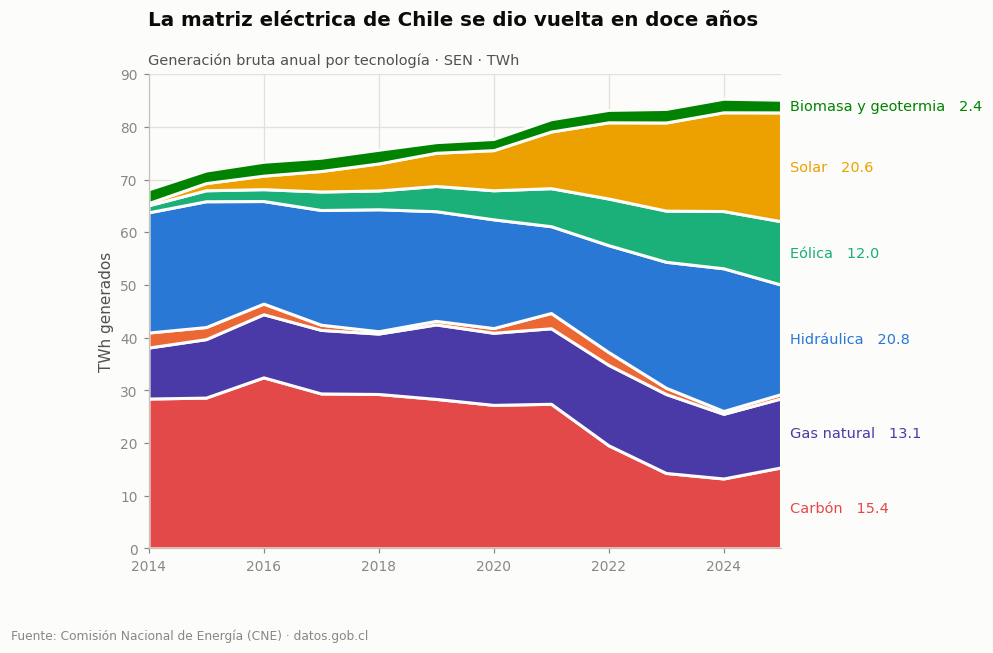

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.6))

ax.stackplot(m.index, [m[g].values for g in ORDEN_GRUPOS],
             colors=[COLORES[g] for g in ORDEN_GRUPOS],
             edgecolor=SUPERFICIE, linewidth=2)

# Etiquetas directas al borde derecho: identidad sin depender solo del color.
ultimo = m.index[-1]
acum = 0.0
for g in ORDEN_GRUPOS:
    v = m.loc[ultimo, g]
    if v >= 2.0:
        etiqueta_derecha(ax, acum + v / 2, f"{g}   {v:.1f}", COLORES[g])
    acum += v

ax.set_xlim(m.index.min(), ultimo)
ax.set_ylim(0, 90)
ax.set_ylabel("TWh generados")
ax.set_xticks(range(2014, 2026, 2))
encabezado(ax, "La matriz eléctrica de Chile se dio vuelta en doce años",
           "Generación bruta anual por tecnología · SEN · TWh")
espacio_etiquetas(fig, 0.70)
fuente(fig)
fig.savefig(ROOT / "figures" / "01_matriz_apilada.png")
plt.show()

El bloque rojo del carbón se encoge; el amarillo del sol aparece de la nada y se
convierte en la segunda fuente del país. Pero un apilado esconde una pregunta
importante: **¿las renovables reemplazaron al carbón, o solo cubrieron demanda
nueva?**

La respuesta está en la altura total del apilado.

In [12]:
a, b = 2014, 2025
total_a, total_b = m.loc[a].sum(), m.loc[b].sum()
print(f"Generación total   {total_a:.1f} -> {total_b:.1f} TWh   (+{100*(total_b/total_a-1):.0f}%)")
print(f"Carbón             {m.loc[a,'Carbón']:.1f} -> {m.loc[b,'Carbón']:.1f} TWh   ({m.loc[b,'Carbón']-m.loc[a,'Carbón']:+.1f})")
nuevas = m.loc[b, ['Solar','Eólica']].sum() - m.loc[a, ['Solar','Eólica']].sum()
print(f"Solar + eólica     {m.loc[a,['Solar','Eólica']].sum():.1f} -> {m.loc[b,['Solar','Eólica']].sum():.1f} TWh   ({nuevas:+.1f})")
print()
print(f"Crecimiento de demanda: {total_b - total_a:+.1f} TWh")
print(f"Aporte nuevo renovable: {nuevas:+.1f} TWh")
print(f"-> sobra para desplazar: {nuevas - (total_b - total_a):.1f} TWh")

Generación total   68.1 -> 85.1 TWh   (+25%)
Carbón             28.4 -> 15.4 TWh   (-13.1)
Solar + eólica     1.8 -> 32.7 TWh   (+30.9)

Crecimiento de demanda: +17.0 TWh
Aporte nuevo renovable: +30.9 TWh
-> sobra para desplazar: 13.9 TWh


Las renovables aportaron 30,9 TWh nuevos mientras la demanda creció 17,0 TWh.
El excedente —**13,9 TWh**— es exactamente lo que se usó para apagar carbón
(13,1 TWh menos). No es contabilidad creativa: es sustitución real.

El cruce se ve mejor con el resto en gris.

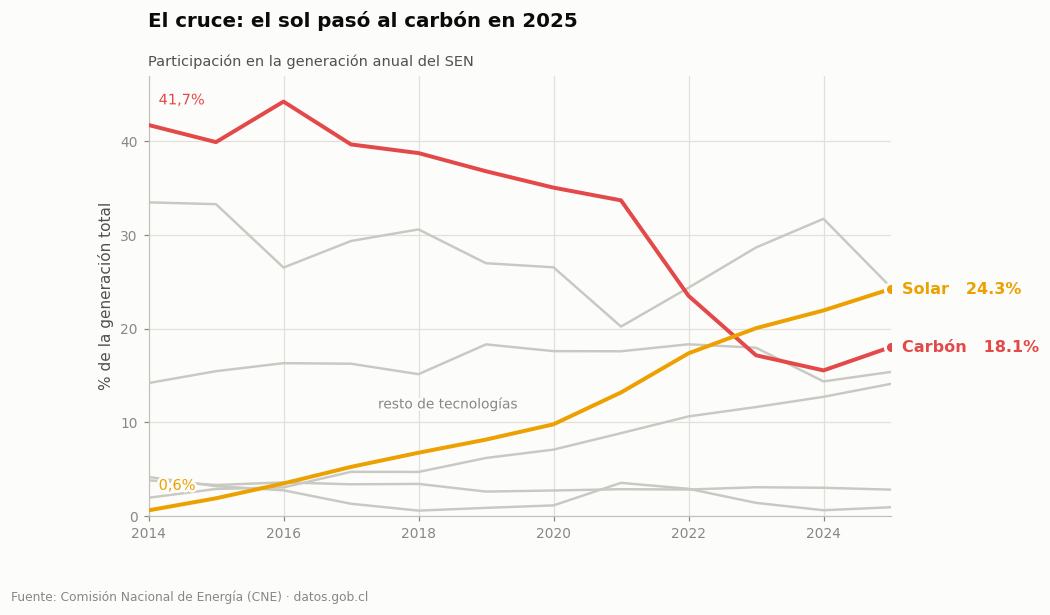

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.2))

for g in ORDEN_GRUPOS:
    if g in ("Carbón", "Solar"):
        continue
    ax.plot(s.index, s[g], color=GRIS_CONTEXTO, linewidth=1.6, zorder=1)

for g in ("Carbón", "Solar"):
    ax.plot(s.index, s[g], color=COLORES[g], linewidth=2.6, zorder=3)
    ax.plot(s.index[-1], s[g].iloc[-1], "o", color=COLORES[g],
            markersize=8, zorder=4, markeredgecolor=SUPERFICIE, markeredgewidth=2)
    etiqueta_derecha(ax, s[g].iloc[-1], f"{g}   {s[g].iloc[-1]:.1f}%", COLORES[g],
                     fontsize=10.5, fontweight="semibold")

# Halo del color del fondo: las etiquetas de contexto cruzan líneas grises.
halo = [pe.withStroke(linewidth=3.5, foreground=SUPERFICIE)]
ax.text(2014.15, s.loc[2014, "Carbón"] + 2.2, "41,7%", color=COLORES["Carbón"],
        fontsize=9.5, path_effects=halo)
ax.text(2014.15, s.loc[2014, "Solar"] + 2.2, "0,6%", color=COLORES["Solar"],
        fontsize=9.5, path_effects=halo)
ax.text(2017.4, 11.5, "resto de tecnologías", color=INK_MUTED, fontsize=9,
        path_effects=halo)

ax.set_xlim(2014, 2025)
ax.set_ylim(0, 47)
ax.set_ylabel("% de la generación total")
ax.set_xticks(range(2014, 2026, 2))
encabezado(ax, "El cruce: el sol pasó al carbón en 2025",
           "Participación en la generación anual del SEN")
espacio_etiquetas(fig, 0.80)
fuente(fig)
fig.savefig(ROOT / "figures" / "02_cruce_carbon_solar.png")
plt.show()

### La tabla, por si el color no basta

Los gráficos de arriba usan amarillo y aqua, que tienen poco contraste sobre
fondo claro. La tabla completa evita que la lectura dependa del color:

In [14]:
(s.round(1)
  .style.format("{:.1f}%")
  .background_gradient(cmap="Blues", axis=None)
  .set_caption("Participación (%) por tecnología y año — SEN"))

grupo,Carbón,Gas natural,Diésel y otros térmicos,Hidráulica,Eólica,Solar,Biomasa y geotermia
anio,,,,,,,
2014,41.7%,14.2%,4.2%,33.5%,2.0%,0.6%,3.8%
2015,39.9%,15.5%,3.2%,33.3%,2.9%,1.9%,3.3%
2016,44.2%,16.3%,2.8%,26.5%,3.1%,3.5%,3.6%
2017,39.7%,16.3%,1.3%,29.4%,4.7%,5.3%,3.4%
2018,38.7%,15.1%,0.6%,30.6%,4.7%,6.8%,3.4%
2019,36.8%,18.3%,0.9%,27.0%,6.2%,8.2%,2.6%
2020,35.1%,17.6%,1.1%,26.6%,7.1%,9.8%,2.7%
2021,33.7%,17.6%,3.6%,20.2%,8.9%,13.2%,2.9%
2022,23.5%,18.3%,2.9%,24.4%,10.6%,17.4%,2.8%


## 5. Acto III — El giro

Si la historia terminara acá sería una buena noticia sin matices. Pero mira la
última columna de la tabla.

In [15]:
ult = s.loc[[2024, 2025]].T
ult["cambio"] = (ult[2025] - ult[2024]).round(1)
ult.sort_values("cambio")

anio,2024,2025,cambio
grupo,,,
Hidráulica,31.729470,24.402322,-7.3
Biomasa y geotermia,3.027778,2.827377,-0.2
Diésel y otros térmicos,0.629560,0.950523,0.3
Gas natural,14.377090,15.393102,1.0
Eólica,12.732786,14.122328,1.4
Solar,21.952369,24.253576,2.3
Carbón,15.550947,18.050772,2.5


**El carbón subió 2,5 puntos en 2025.** Primera alza en cuatro años. Y la
hidráulica cayó 7,3 puntos.

Eso no es casualidad ni retroceso de política: es la consecuencia de que la
matriz renovable chilena sigue necesitando respaldo firme. Cuando falla la
hidrología, alguien tiene que cubrir. Y quien cubre es el carbón.

Para ver por qué, hay que bajar del año al mes.

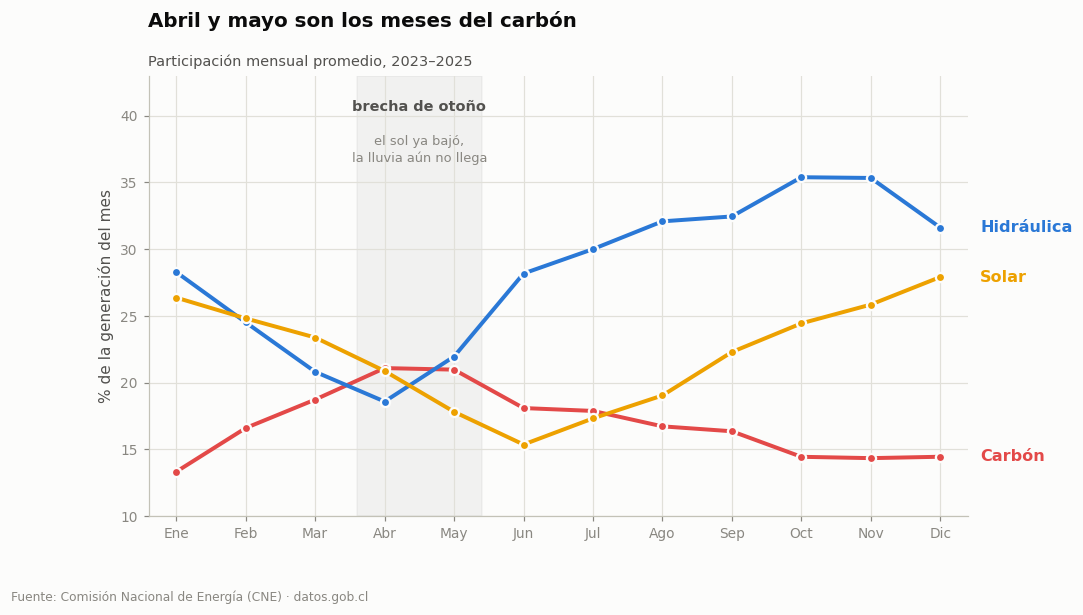

In [16]:
recientes = df[df.anio.between(2023, 2025)]
pm = recientes.pivot_table(index="mes", columns="grupo", values="generacion_mwh",
                           aggfunc="sum", observed=True)
estacional = pm.div(pm.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.2))
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

for g in ["Carbón", "Hidráulica", "Solar"]:
    ax.plot(estacional.index, estacional[g], color=COLORES[g], linewidth=2.6,
            marker="o", markersize=6, markeredgecolor=SUPERFICIE, markeredgewidth=1.5)
    etiqueta_derecha(ax, estacional[g].iloc[-1], g, COLORES[g],
                     fontsize=10.5, fontweight="semibold")

ax.axvspan(3.6, 5.4, color="#0b0b0b", alpha=0.045, zorder=0)
ax.text(4.5, 40.4, "brecha de otoño", ha="center", fontsize=9.5,
        color=INK_SEC, fontweight="semibold")
ax.text(4.5, 38.6, "el sol ya bajó,\nla lluvia aún no llega", ha="center",
        fontsize=8.5, color=INK_MUTED, linespacing=1.4, va="top")

ax.set_xticks(range(1, 13), meses)
ax.set_xlim(0.6, 12.4)
ax.set_ylim(10, 43)
ax.set_ylabel("% de la generación del mes")
encabezado(ax, "Abril y mayo son los meses del carbón",
           "Participación mensual promedio, 2023–2025")
espacio_etiquetas(fig, 0.87)
fuente(fig)
fig.savefig(ROOT / "figures" / "03_brecha_otono.png")
plt.show()

In [17]:
print("Participación del carbón por mes (2023-2025):")
print(f"  mínimo  {estacional.Carbón.min():.1f}%  ({meses[estacional.Carbón.idxmin()-1]})")
print(f"  máximo  {estacional.Carbón.max():.1f}%  ({meses[estacional.Carbón.idxmax()-1]})")
print(f"  brecha  {estacional.Carbón.max() - estacional.Carbón.min():.1f} puntos")
print()
print(f"Solar en diciembre: {estacional.loc[12,'Solar']:.1f}%   en junio: {estacional.loc[6,'Solar']:.1f}%")

Participación del carbón por mes (2023-2025):
  mínimo  13.3%  (Ene)
  máximo  21.1%  (Abr)
  brecha  7.8 puntos

Solar en diciembre: 27.9%   en junio: 15.4%


El carbón oscila entre 13,3% y 21,1% según el mes. Su máximo cae **exactamente**
en el valle entre las dos renovables grandes: el sol ya perdió fuerza (baja de
27,9% en diciembre a 15,4% en junio) y la hidrología todavía no repunta.

La transición no falla por falta de capacidad renovable. Falla ocho semanas al
año.

### Y falla en un lugar concreto

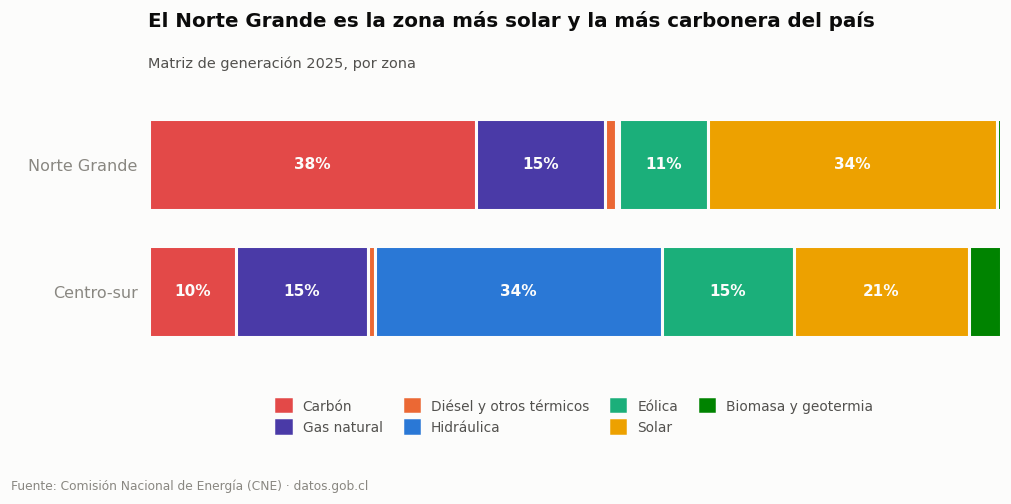

In [18]:
z = df[df.anio == 2025].pivot_table(index="zona", columns="grupo",
                                    values="generacion_mwh", aggfunc="sum",
                                    observed=True)
z = (z.div(z.sum(axis=1), axis=0) * 100).reindex(["Norte Grande", "Centro-sur"])

fig, ax = plt.subplots(figsize=(10, 3.6))
izq = np.zeros(len(z))
for g in ORDEN_GRUPOS:
    ax.barh(z.index, z[g], left=izq, color=COLORES[g], height=0.72,
            edgecolor=SUPERFICIE, linewidth=2)
    for i, (v, l) in enumerate(zip(z[g], izq)):
        if v >= 9:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    color=SUPERFICIE, fontsize=10, fontweight="bold")
    izq += z[g].values

ax.set_xlim(0, 100)
ax.set_ylim(1.7, -0.7)
ax.grid(False)
ax.set_xticks([])
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(left=False, labelsize=10.5)
encabezado(ax, "El Norte Grande es la zona más solar y la más carbonera del país",
           "Matriz de generación 2025, por zona")

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORES[g]) for g in ORDEN_GRUPOS]
ax.legend(handles, ORDEN_GRUPOS, loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncol=4, frameon=False, handlelength=1.1, handleheight=1.1,
          columnspacing=1.6)
fuente(fig, y=-0.14)
fig.savefig(ROOT / "figures" / "04_zonas.png")
plt.show()

In [19]:
comp = df[df.anio == 2025].pivot_table(index="zona", columns="grupo",
                                       values="generacion_mwh", aggfunc="sum",
                                       observed=True)
comp_pct = (comp.div(comp.sum(axis=1), axis=0) * 100).round(1)
print(comp_pct[["Carbón", "Solar", "Hidráulica"]].to_string())
print()
print(f"TWh Norte Grande: {comp.loc['Norte Grande'].sum()/1e6:.1f}")
print(f"TWh Centro-sur:   {comp.loc['Centro-sur'].sum()/1e6:.1f}")

grupo         Carbón  Solar  Hidráulica
zona                                   
Centro-sur      10.3   20.6        33.6
Norte Grande    38.4   33.8         0.3

TWh Norte Grande: 23.5
TWh Centro-sur:   61.6


Acá está la contradicción completa. El Norte Grande:

- genera **33,8%** de su electricidad con sol — la mayor proporción del país;
- genera **38,4%** con carbón — casi cuatro veces más que el centro-sur;
- tiene **0,3%** de hidráulica.

No es una paradoja: es la consecuencia directa de las dos cosas anteriores. El
norte tiene el mejor sol del mundo y ninguna hidroelectricidad que le sirva de
respaldo. La minería consume las 24 horas. Y el sol se apaga todas las noches.

Sin almacenamiento ni transmisión que traiga energía del sur, la única forma de
sostener la noche del norte es quemar algo.

## 6. Una nota sobre concentración

Un último dato, porque cambia cómo se leen los anteriores:

In [20]:
c = df[df.anio == 2025].groupby("codigo_central").generacion_mwh.sum().sort_values(ascending=False)
cum = c.cumsum() / c.sum()
n80 = int((cum <= 0.80).sum())
print(f"Centrales que operaron en 2025: {len(c):,}".replace(",", "."))
print(f"Centrales que generan el 80%:   {n80}  ({100*n80/len(c):.1f}%)")
print()
print("Top 5:")
for nombre, mwh in c.head(5).items():
    print(f"  {nombre:28s} {mwh/1e6:5.2f} TWh  ({100*mwh/c.sum():4.1f}%)")

Centrales que operaron en 2025: 1.247
Centrales que generan el 80%:   148  (11.9%)

Top 5:
  San Isidro II GNL             1.95 TWh  ( 2.3%)
  IE Mejillones                 1.74 TWh  ( 2.0%)
  Pehuenche                     1.63 TWh  ( 1.9%)
  El Toro                       1.52 TWh  ( 1.8%)
  eang1                         1.51 TWh  ( 1.8%)


**148 centrales de 1.247 generan el 80% de la electricidad del país.** Las otras
1.099 —casi todas plantas solares pequeñas— aportan el 20% restante.

Eso explica por qué las 732 plantas solares no se traducen en 732 unidades de
resiliencia: son muchas, chicas, y todas producen a la misma hora.

---

## Conclusiones

**La transición chilena es real y es rápida.** El carbón pasó de 41,7% a 18,1%
de la generación en once años, y no porque cayera la demanda: la generación
total creció 25% en el mismo período. Solar y eólica aportaron 30,9 TWh nuevos
—casi el doble de lo que creció la demanda— y el excedente apagó centrales a
carbón.

**Pero el retroceso de 2025 no es ruido.** Cuando la hidrología falló, el carbón
recuperó 2,5 puntos en un año. Eso revela que la matriz sigue teniendo una
dependencia estructural de respaldo firme, y que ese respaldo hoy es fósil.

**El problema ya no es de generación, sino de sincronía.** Los datos muestran
dos brechas concretas:

- **Temporal:** el carbón toca su máximo en abril–mayo (21,1%), justo cuando el
  sol bajó y la lluvia no llegó. Ocho semanas al año definen el resultado.
- **Geográfica:** el Norte Grande es a la vez la zona más solar (33,8%) y la más
  carbonera (38,4%) del país, porque no tiene hidroelectricidad de respaldo y su
  demanda minera no se apaga de noche.

Ambas brechas apuntan al mismo lugar: **almacenamiento y transmisión**, no más
paneles.

### Límites de este análisis

- Los datos son **mensuales**. La brecha de otoño se ve; la curva diaria —donde
  vive el problema real del almacenamiento— no. Con datos horarios del
  Coordinador Eléctrico se podría medir directamente.
- `subsistema` (SIC/SING) es una etiqueta **histórica**: ambos sistemas se
  interconectaron en el SEN en noviembre de 2017. La uso como proxy geográfico
  estable —ninguna central cambia de etiqueta en toda la serie— pero no describe
  la operación actual del sistema.
- El dataset mide **generación**, no capacidad instalada ni vertimiento
  (*curtailment*). No puedo cuantificar cuánta energía solar se descartó por
  falta de transmisión, que es la continuación natural de este análisis.
- 2026 está incompleto (solo enero y febrero) y queda fuera de todas las
  comparaciones anuales.